# NB10 — Clasificador morfológico temprano: ¿puede predecirse C4/C5 en los primeros segundos de la caída?

## Motivación

El módulo NB09 demostró que el AND gate simple (predicción NB08 + señal de caída ≥2 pp) no mejora el PPV de manera significativa: la causa es que los eventos no severos (C1-C3) generan señal de caída con la misma frecuencia que los severos, lo que hace que el filtro no discrimine.

La pregunta que NB10 responde es más precisa: **dado que una caída de SpO₂ acaba de comenzar, ¿pueden los primeros N segundos de la curva predecir si el evento será C4/C5 antes de que el nadir se alcance?**

Si la respuesta es afirmativa con N pequeño (5-15s), existe una ventana temporal útil entre la detección del inicio de la caída y el nadir del evento para activar el estimulador con información morfológica. Combinado con la predicción NB08 activa, este clasificador formaría el núcleo de un **AND gate inteligente**:

```
TRIGGER = (NB08 predice evento severo en próximos 5 min)
        AND (se detecta inicio de caída)
        AND (clasificador morfológico temprano clasifica como C4/C5)
```

## Diseño

- **Corpus**: 83.694 eventos strict (8 pacientes) con curvas de 30 puntos de SpO₂
- **Feature**: primeros N puntos de la curva SpO₂ normalizados respecto al punto inicial (valor[i] / valor[0])
- **Target**: es_severo = morphotype_curve ∈ {C4, C5}  (5,7 % del corpus)
- **Validación**: LOPO-CV estricto (8 folds, mismo protocolo que NB08)
- **N evaluados**: 5, 10, 15, 20 puntos (~5, 10, 15, 20 segundos de señal)
- **Modelos**: LightGBM + Regresión Logística como baseline lineal

## Pregunta operacional clave

¿Con cuántos segundos de curva el clasificador temprano supera el AUC del AND gate simple (AUC ≈ sin mejora sobre baseline)? Si con N=10s se obtiene AUC > 0,70, el clasificador es útil como segundo filtro.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
from sklearn.ensemble import HistGradientBoostingClassifier as LGBMClassifier
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

GOLD   = '../gold'
FIGDIR = 'figuras'
import os; os.makedirs(FIGDIR, exist_ok=True)

PAC_BLUE   = '#1E3A5F'
PAC_GRAY   = '#6B7280'
PAC_GREEN  = '#1A7A4A'
PAC_RED    = '#C0392B'
PAC_ORANGE = '#E67E22'

N_POINTS = [5, 10, 15, 20]   # segundos de curva disponibles
H_OPT    = 5                  # horizonte NB08
NB08_PPV = 0.203              # baseline NB08 H=5min

print('Setup OK ✓')

Setup OK ✓


---
## Bloque A — Construcción del corpus de curvas parciales

Cada evento se representa como su curva de SpO₂ normalizada respecto al valor inicial (punto 0). La normalización hace que el clasificador sea independiente del nivel basal absoluto de SpO₂ de cada paciente, capturando solo la morfología de la caída.

Para cada N evaluado, la feature matrix tiene N−1 columnas (la razón pt[i]/pt[0] para i=1..N−1; pt[0]/pt[0]=1 siempre, se omite). Se añade una feature adicional: el slope estimado (caída media por punto en los primeros N puntos), que captura la velocidad de la desaturación y es clínicamente informativo.

In [3]:
# Cargar y mergear curvas con morfotipos
ev = pd.read_parquet(f'{GOLD}/events.parquet')
ec = pd.read_parquet(f'{GOLD}/events_curves.parquet')

df = ev.merge(ec, on=['night_record_id','ts_start'], how='inner')
strict_users = ['175','240','309','314','321','336','656','683']
df = df[df['in_strict'] & df['morphotype_curve'].notna() &
        df['user_id'].isin(strict_users)].copy()

df['is_severe'] = df['morphotype_curve'].isin(['C4','C5']).astype(int)
df['curve_arr'] = df['spo2_curve'].apply(np.array)

print(f'Corpus: {len(df):,} eventos | {df["user_id"].nunique()} pacientes')
print(f'Severos (C4/C5): {df["is_severe"].sum():,} ({df["is_severe"].mean()*100:.1f}%)')
print()
for uid, g in df.groupby('user_id'):
    n_s = g['is_severe'].sum()
    print(f'  Pac {uid}: {len(g):,} eventos, {n_s:,} severos ({n_s/len(g)*100:.1f}%)')

def build_features(df, n_pts):
    """Features: primeros n_pts puntos normalizados + slope."""
    X = []
    for arr in df['curve_arr']:
        if len(arr) >= n_pts:
            pts = arr[:n_pts]
            norm = pts / pts[0] if pts[0] > 0 else pts / (pts[0] + 1e-6)
            # Ratios pt[1..n-1] / pt[0] (pt[0]/pt[0]=1 se omite)
            feats = list(norm[1:])
            # Slope: caída media por punto (negativo = caída)
            slope = (norm[-1] - norm[0]) / (n_pts - 1)
            # Max caída hasta el momento
            min_norm = norm.min()
            feats += [slope, min_norm]
        else:
            feats = [np.nan] * (n_pts - 1 + 2)
        X.append(feats)
    return np.array(X, dtype=float)

print()
print(f'Features para N=10: {build_features(df.head(3), 10).shape[1]} columnas')
print('  (9 ratios normalizados + slope + min_norm)')

Corpus: 83,694 eventos | 8 pacientes
Severos (C4/C5): 4,782 (5.7%)

  Pac 175: 8,928 eventos, 1,148 severos (12.9%)
  Pac 240: 3,258 eventos, 271 severos (8.3%)
  Pac 309: 6,971 eventos, 318 severos (4.6%)
  Pac 314: 509 eventos, 12 severos (2.4%)
  Pac 321: 10,044 eventos, 431 severos (4.3%)
  Pac 336: 23,182 eventos, 1,020 severos (4.4%)
  Pac 656: 21,839 eventos, 859 severos (3.9%)
  Pac 683: 8,963 eventos, 723 severos (8.1%)

Features para N=10: 11 columnas
  (9 ratios normalizados + slope + min_norm)


---
## Bloque B — LOPO-CV: ¿con cuántos segundos discrimina el clasificador?

Para cada N (segundos de curva disponibles), se entrena LightGBM con LOPO-CV y se evalúa el AUC de discriminación severo vs. no severo.

La hipótesis es que la curva de AUC vs. N crece rápidamente en los primeros 10-15 segundos: la forma inicial de la desaturación (velocidad, perfil de caída) ya revela si el evento irá hacia morfotipo severo. Si esto se confirma, el clasificador es útil para el AND gate inteligente.

**Nota**: el AUC aquí es sobre **todos los eventos** (no solo ventanas con predicción NB08 activa). El bloque D combina ambas fuentes.

In [4]:
print('LOPO-CV clasificador morfológico temprano...')
print(f'{"N (seg)":<10} {"AUC LGB":>10} {"AP LGB":>10} {"AUC LR":>10} {"AP LR":>10}  {"Baseline":>10}')
print('-' * 60)

results = {}
patients = sorted(df['user_id'].unique())

for n_pts in N_POINTS:
    X_all = build_features(df, n_pts)
    y_all = df['is_severe'].values
    uid_all = df['user_id'].values
    base = y_all.mean()

    # Imputar NaN con mediana global
    from sklearn.impute import SimpleImputer
    imp = SimpleImputer(strategy='median')
    X_all = imp.fit_transform(X_all)

    prob_lgb = np.zeros(len(df))
    prob_lr  = np.zeros(len(df))

    for uid in patients:
        test_mask  = (uid_all == uid)
        train_mask = ~test_mask
        X_tr, y_tr = X_all[train_mask], y_all[train_mask]
        X_te       = X_all[test_mask]
        # LightGBM
        lgb = LGBMClassifier(max_iter=200, learning_rate=0.05,
                             max_leaf_nodes=31, min_samples_leaf=20,
                             class_weight='balanced', random_state=42)
        lgb.fit(X_tr, y_tr)
        prob_lgb[test_mask] = lgb.predict_proba(X_te)[:,1]
        # LR
        lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
        lr.fit(X_tr, y_tr)
        prob_lr[test_mask] = lr.predict_proba(X_te)[:,1]

    auc_lgb = roc_auc_score(y_all, prob_lgb)
    ap_lgb  = average_precision_score(y_all, prob_lgb)
    auc_lr  = roc_auc_score(y_all, prob_lr)
    ap_lr   = average_precision_score(y_all, prob_lr)

    results[n_pts] = dict(auc_lgb=auc_lgb, ap_lgb=ap_lgb,
                          auc_lr=auc_lr,   ap_lr=ap_lr,
                          prob_lgb=prob_lgb, prob_lr=prob_lr,
                          baseline=base)
    print(f'{n_pts:>4} seg     {auc_lgb:>10.3f} {ap_lgb:>10.3f} {auc_lr:>10.3f} {ap_lr:>10.3f}  {base:>10.3f}')

print()
print('Referencia NB08 (nivel noche): AUC=0.821 (tarea distinta, no comparable directamente)')
print('Referencia NB07 evento condicionado: AUC=0.878 (evento ya en curso, curva completa)')

LOPO-CV clasificador morfológico temprano...
N (seg)       AUC LGB     AP LGB     AUC LR      AP LR    Baseline
------------------------------------------------------------
   5 seg          0.793      0.202      0.760      0.210       0.057
  10 seg          0.866      0.289      0.835      0.290       0.057
  15 seg          0.933      0.515      0.898      0.454       0.057
  20 seg          0.977      0.795      0.945      0.677       0.057

Referencia NB08 (nivel noche): AUC=0.821 (tarea distinta, no comparable directamente)
Referencia NB07 evento condicionado: AUC=0.878 (evento ya en curso, curva completa)


In [5]:
# Análisis del umbral operacional para N=10 (punto clave)
for n_key in N_POINTS:
    r = results[n_key]
    y_all = df['is_severe'].values
    prob = r['prob_lgb']
    fpr, tpr, thrs = roc_curve(y_all, prob)
    j = tpr - fpr
    idx = np.argmax(j)
    thr = thrs[idx]
    y_pred = (prob >= thr).astype(int)
    tp = ((y_pred==1)&(y_all==1)).sum()
    fp = ((y_pred==1)&(y_all==0)).sum()
    fn = ((y_pred==0)&(y_all==1)).sum()
    ppv  = tp/(tp+fp) if (tp+fp)>0 else 0
    sens = tp/(tp+fn) if (tp+fn)>0 else 0
    ratio= fp/tp if tp>0 else float('inf')
    results[n_key].update(thr=thr, ppv=ppv, sens=sens, ratio=ratio)
    star = ' ◄' if n_key == 10 else ''
    print(f'N={n_key:2d}s  Thr={thr:.3f}  Sens={sens*100:.0f}%  PPV={ppv*100:.0f}%  Ratio={ratio:.1f}:1{star}')

N= 5s  Thr=0.470  Sens=73%  PPV=16%  Ratio=5.4:1
N=10s  Thr=0.418  Sens=84%  PPV=19%  Ratio=4.2:1 ◄
N=15s  Thr=0.402  Sens=89%  PPV=27%  Ratio=2.7:1
N=20s  Thr=0.293  Sens=94%  PPV=39%  Ratio=1.6:1


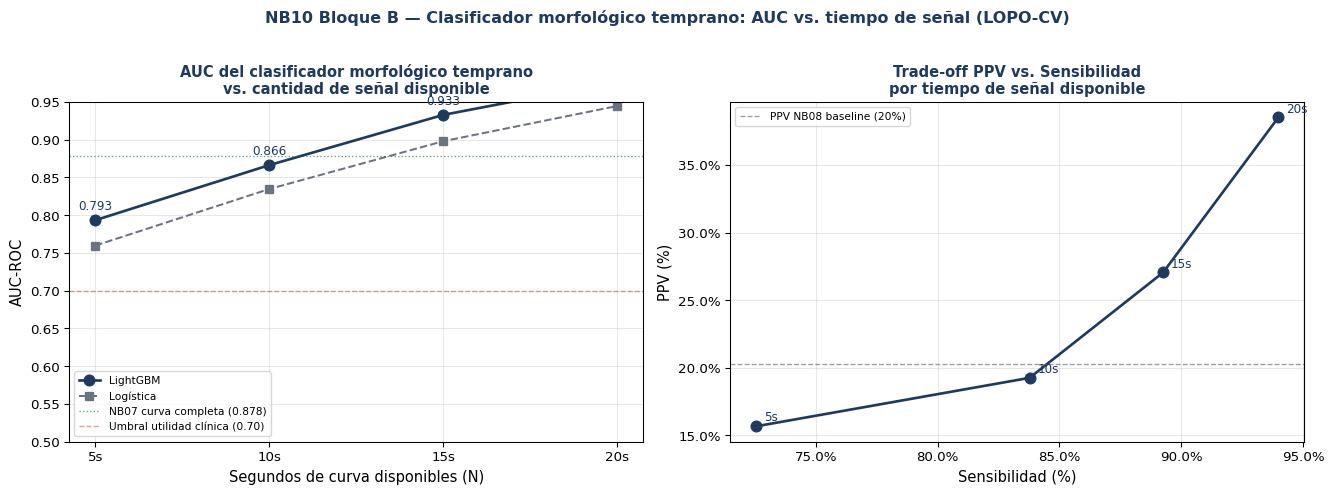

→ figuras/10B_clasificador_temprano_auc.png


In [6]:
# Figura B1: AUC vs. segundos de curva disponibles
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=96)

ns = N_POINTS
auc_lgbs = [results[n]['auc_lgb'] for n in ns]
auc_lrs  = [results[n]['auc_lr']  for n in ns]
ap_lgbs  = [results[n]['ap_lgb']  for n in ns]

ax = axes[0]
ax.plot(ns, auc_lgbs, 'o-', color=PAC_BLUE, lw=2, ms=8, label='LightGBM')
ax.plot(ns, auc_lrs,  's--', color=PAC_GRAY, lw=1.5, ms=6, label='Logística')
ax.axhline(0.878, color=PAC_GREEN, lw=1, ls=':', alpha=0.7,
           label='NB07 curva completa (0.878)')
ax.axhline(0.70,  color=PAC_RED, lw=1, ls='--', alpha=0.5,
           label='Umbral utilidad clínica (0.70)')
for n, a in zip(ns, auc_lgbs):
    ax.annotate(f'{a:.3f}', (n, a), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=9, color=PAC_BLUE)
ax.set_xlabel('Segundos de curva disponibles (N)', fontsize=11)
ax.set_ylabel('AUC-ROC', fontsize=11)
ax.set_title('AUC del clasificador morfológico temprano\nvs. cantidad de señal disponible',
             fontsize=11, fontweight='bold', color=PAC_BLUE)
ax.legend(fontsize=8); ax.set_ylim(0.5, 0.95)
ax.set_xticks(ns); ax.set_xticklabels([f'{n}s' for n in ns])
ax.grid(True, alpha=0.3)

ax = axes[1]
ppvs_lgb = [results[n]['ppv']*100 for n in ns]
senss_lgb= [results[n]['sens']*100 for n in ns]
ax.plot(senss_lgb, ppvs_lgb, 'o-', color=PAC_BLUE, lw=2, ms=8)
for n, s, p in zip(ns, senss_lgb, ppvs_lgb):
    ax.annotate(f'{n}s', (s, p), textcoords='offset points',
                xytext=(6, 4), fontsize=9, color=PAC_BLUE)
ax.axhline(NB08_PPV*100, color=PAC_GRAY, lw=1, ls='--', alpha=0.7,
           label=f'PPV NB08 baseline ({NB08_PPV*100:.0f}%)')
ax.set_xlabel('Sensibilidad (%)', fontsize=11)
ax.set_ylabel('PPV (%)', fontsize=11)
ax.set_title('Trade-off PPV vs. Sensibilidad\npor tiempo de señal disponible',
             fontsize=11, fontweight='bold', color=PAC_BLUE)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

fig.suptitle('NB10 Bloque B — Clasificador morfológico temprano: AUC vs. tiempo de señal (LOPO-CV)',
             fontsize=12, fontweight='bold', color=PAC_BLUE, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/10B_clasificador_temprano_auc.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'→ {FIGDIR}/10B_clasificador_temprano_auc.png')

---
## Bloque C — AUC por paciente: estabilidad del clasificador temprano

El AUC global LOPO-CV puede ocultar heterogeneidad inter-paciente importante. Un paciente con muy pocos eventos severos (como Pac314, n=12) puede producir un fold con AUC inestable. Este bloque examina la estabilidad del clasificador para N=10s (el punto operacional más relevante) fold a fold.

In [7]:
# AUC por paciente para N=10
n_key = 10
r = results[n_key]
y_all = df['is_severe'].values
prob  = r['prob_lgb']
uid_all = df['user_id'].values

print(f'── Estabilidad por paciente (N={n_key}s, LightGBM LOPO-CV) ──\n')
print(f'{"Paciente":<10} {"n_eventos":>10} {"n_severos":>10} {"prev%":>8} {"AUC":>8} {"AP":>8}')
print('-' * 56)
for uid in sorted(df['user_id'].unique()):
    mask = uid_all == uid
    y_u  = y_all[mask]
    p_u  = prob[mask]
    n_s  = y_u.sum()
    prev = y_u.mean()*100
    if n_s >= 2 and (1-y_u).sum() >= 2:
        auc_u = roc_auc_score(y_u, p_u)
        ap_u  = average_precision_score(y_u, p_u)
        print(f'Pac {uid:<6} {mask.sum():>10,} {n_s:>10,} {prev:>7.1f}% {auc_u:>8.3f} {ap_u:>8.3f}')
    else:
        print(f'Pac {uid:<6} {mask.sum():>10,} {n_s:>10,} {prev:>7.1f}%  {"n/a":>8} {"n/a":>8}  (insuf. severos)')
print()
print(f'Global  {len(df):>10,} {y_all.sum():>10,} {y_all.mean()*100:>7.1f}% {r["auc_lgb"]:>8.3f} {r["ap_lgb"]:>8.3f}')

── Estabilidad por paciente (N=10s, LightGBM LOPO-CV) ──

Paciente    n_eventos  n_severos    prev%      AUC       AP
--------------------------------------------------------
Pac 175         8,928      1,148    12.9%    0.940    0.722
Pac 240         3,258        271     8.3%    0.877    0.441
Pac 309         6,971        318     4.6%    0.915    0.459
Pac 314           509         12     2.4%    0.921    0.604
Pac 321        10,044        431     4.3%    0.842    0.258
Pac 336        23,182      1,020     4.4%    0.834    0.185
Pac 656        21,839        859     3.9%    0.844    0.225
Pac 683         8,963        723     8.1%    0.877    0.438

Global      83,694      4,782     5.7%    0.866    0.289


---
## Bloque D — AND gate inteligente: NB08 + clasificador morfológico temprano

Este es el resultado central de NB10. El AND gate inteligente combina:
1. **NB08**: predicción activa (p_severe_5min > umbral global = 0,459)
2. **Señal de caída**: inicio de evento detectado (≥2 pp)
3. **Clasificador morfológico temprano** (N=10s): el evento iniciado es clasificado como probable C4/C5

Las tres condiciones deben cumplirse simultáneamente para que el estimulador se active.

La pregunta clave: ¿el tercer filtro (morfológico) mejora el PPV respecto al AND gate simple de NB09 (PPV=20,8 %) sin sacrificar demasiada sensibilidad?

### Método de simulación

Para cada ventana con señal de caída activa en `window_risk_predictions.parquet`:
- Se identifica el EDO que coincide con esa ventana
- Se aplica el clasificador morfológico temprano con N=10s (prob_lgb del evento)
- Si prob_lgb > umbral morfológico Y NB08 activo → trigger AND gate inteligente

In [8]:
# Merge predicciones NB08 con clasificación morfológica temprana
wrp = pd.read_parquet(f'{GOLD}/window_risk_predictions.parquet')
h = H_OPT
THR_NB08 = 0.459

# Añadir prob morfológica al dataframe de eventos
n_key = 10
df['prob_severe_early'] = results[n_key]['prob_lgb']

# Para cada ventana en wrp, encontrar si hay un evento que empieza en la ventana
# y obtener su prob_severe_early
ev_strict = df[['user_id','night_record_id','ts_start','ts_end',
                'morphotype_curve','is_severe','prob_severe_early']].copy()
ev_strict['ts_start'] = pd.to_datetime(ev_strict['ts_start'])
ev_strict['ts_end']   = pd.to_datetime(ev_strict['ts_end'])

TOLERANCE_S = 30
print(f'Construyendo AND gate inteligente (N={n_key}s, tolerancia ±{TOLERANCE_S}s)...')

# Para cada ventana: encontrar evento más probable que empieza en la ventana
wrp2 = wrp.copy()
wrp2['has_drop']        = False
wrp2['drop_is_severe']  = False   # ground truth del evento que empieza
wrp2['prob_morph_early']= np.nan  # prob del clasificador morfológico

for uid in sorted(wrp2['user_id'].unique()):
    mask_w = wrp2['user_id'] == uid
    ev_u   = ev_strict[ev_strict['user_id'] == uid].sort_values('ts_start')
    if len(ev_u) == 0:
        continue

    ev_ts  = ev_u['ts_start'].values.astype('datetime64[ns]')
    tol    = np.timedelta64(TOLERANCE_S, 's')
    t_lo   = (wrp2.loc[mask_w, 't_start'] - pd.Timedelta(seconds=TOLERANCE_S)).values.astype('datetime64[ns]')
    t_hi   = (wrp2.loc[mask_w, 't_end']   + pd.Timedelta(seconds=TOLERANCE_S)).values.astype('datetime64[ns]')
    w_idx  = wrp2.index[mask_w]

    for i, (lo, hi) in enumerate(zip(t_lo, t_hi)):
        hits = ev_u[(ev_ts >= lo) & (ev_ts <= hi)]
        if len(hits) > 0:
            # Tomar el evento más temprano
            best = hits.iloc[0]
            wrp2.at[w_idx[i], 'has_drop']         = True
            wrp2.at[w_idx[i], 'drop_is_severe']   = bool(best['is_severe'])
            wrp2.at[w_idx[i], 'prob_morph_early']  = float(best['prob_severe_early'])

print(f'Ventanas con drop signal: {wrp2["has_drop"].sum():,} ({wrp2["has_drop"].mean()*100:.1f}%)')
print(f'  Con evento severo real:  {wrp2["drop_is_severe"].sum():,}')
print(f'  Con evento no severo:    {(wrp2["has_drop"] & ~wrp2["drop_is_severe"]).sum():,}')

Construyendo AND gate inteligente (N=10s, tolerancia ±30s)...
Ventanas con drop signal: 189,998 (41.9%)
  Con evento severo real:  9,950
  Con evento no severo:    180,048


In [9]:
# Evaluar AND gate inteligente con distintos umbrales morfológicos
y_true  = wrp2[f'y_{h}min'].values
y_nb08  = (wrp2[f'p_severe_{h}min'].values >= THR_NB08).astype(int)
has_drop= wrp2['has_drop'].values
p_morph = wrp2['prob_morph_early'].fillna(0).values

def gate_metrics(y_t, y_pred):
    tp = int(((y_pred==1)&(y_t==1)).sum())
    fp = int(((y_pred==1)&(y_t==0)).sum())
    fn = int(((y_pred==0)&(y_t==1)).sum())
    ppv   = tp/(tp+fp) if (tp+fp)>0 else 0
    sens  = tp/(tp+fn) if (tp+fn)>0 else 0
    ratio = fp/tp if tp>0 else float('inf')
    return dict(tp=tp, fp=fp, fn=fn, ppv=ppv, sens=sens,
                activations=int(y_pred.sum()), ratio=ratio)

# Baseline NB08
m_nb08 = gate_metrics(y_true, y_nb08)

# AND gate simple (NB09)
y_and_simple = (y_nb08 & has_drop).astype(int)
m_and_simple = gate_metrics(y_true, y_and_simple)

# AND gate inteligente: distintos umbrales morfológicos
print('── AND gate inteligente (NB08 + drop + clasificador morfológico N=10s) ──\n')
print(f'{"Thr morph":<12} {"PPV":>8} {"Sens":>8} {"Ratio":>8} {"Activaciones":>14} {"ΔPPV vs NB08":>14}')
print('-' * 66)
gate_results = {}
for thr_m in [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]:
    y_pred = (y_nb08 & has_drop & (p_morph >= thr_m)).astype(int)
    m = gate_metrics(y_true, y_pred)
    gate_results[thr_m] = m
    delta = (m['ppv'] - m_nb08['ppv'])*100
    print(f'{thr_m:<12.2f} {m["ppv"]*100:>7.1f}% {m["sens"]*100:>7.1f}% {m["ratio"]:>7.1f}:1 '
          f'{m["activations"]:>14,}  {delta:>+13.1f}pp')

print()
print(f'Referencia — NB08 solo:       PPV={m_nb08["ppv"]*100:.1f}%  Sens={m_nb08["sens"]*100:.1f}%  Ratio={m_nb08["ratio"]:.1f}:1  Act={m_nb08["activations"]:,}')
print(f'Referencia — AND simple (NB09): PPV={m_and_simple["ppv"]*100:.1f}%  Sens={m_and_simple["sens"]*100:.1f}%  Ratio={m_and_simple["ratio"]:.1f}:1  Act={m_and_simple["activations"]:,}')

── AND gate inteligente (NB08 + drop + clasificador morfológico N=10s) ──

Thr morph         PPV     Sens    Ratio   Activaciones   ΔPPV vs NB08
------------------------------------------------------------------
0.10            21.0%    23.5%     3.8:1         40,885           +0.7pp
0.15            20.3%    13.7%     3.9:1         24,656           -0.0pp
0.20            20.2%    12.4%     3.9:1         22,332           -0.0pp
0.25            20.0%    10.8%     4.0:1         19,712           -0.3pp
0.30            20.0%     9.5%     4.0:1         17,271           -0.3pp
0.40            20.0%     7.7%     4.0:1         13,956           -0.3pp
0.50            20.0%     6.6%     4.0:1         12,036           -0.3pp

Referencia — NB08 solo:       PPV=20.3%  Sens=75.4%  Ratio=3.9:1  Act=135,434
Referencia — AND simple (NB09): PPV=20.8%  Sens=32.1%  Ratio=3.8:1  Act=56,342


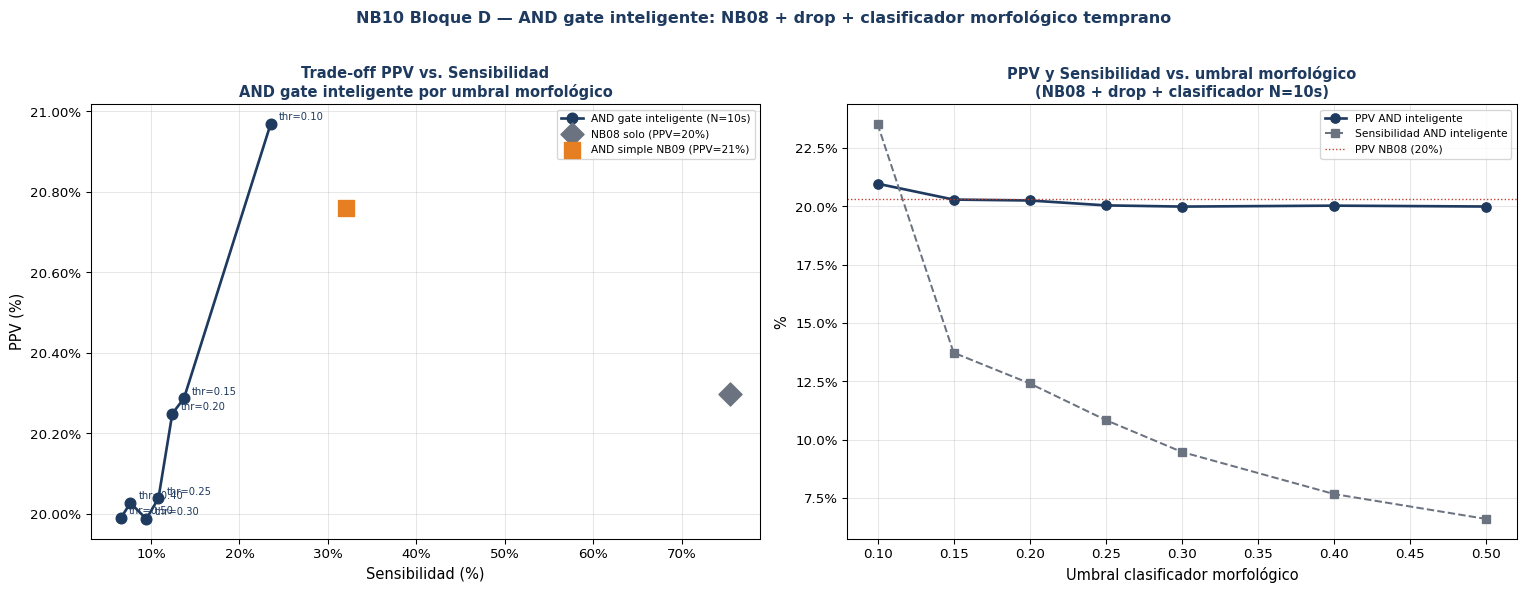

→ figuras/10D_and_gate_inteligente.png


In [10]:
# Figura D1: curva PPV vs Sensibilidad para distintos umbrales morfológicos
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=96)

thrs_m = sorted(gate_results.keys())
ppvs_g = [gate_results[t]['ppv']*100 for t in thrs_m]
sens_g = [gate_results[t]['sens']*100 for t in thrs_m]

ax = axes[0]
ax.plot(sens_g, ppvs_g, 'o-', color=PAC_BLUE, lw=2, ms=8, label=f'AND gate inteligente (N=10s)')
for t, s, p in zip(thrs_m, sens_g, ppvs_g):
    ax.annotate(f'thr={t:.2f}', (s, p), textcoords='offset points',
                xytext=(6, 3), fontsize=7.5, color=PAC_BLUE)
ax.scatter([m_nb08['sens']*100], [m_nb08['ppv']*100],
           color=PAC_GRAY, s=150, zorder=5, marker='D', label=f'NB08 solo (PPV={m_nb08["ppv"]*100:.0f}%)')
ax.scatter([m_and_simple['sens']*100], [m_and_simple['ppv']*100],
           color=PAC_ORANGE, s=150, zorder=5, marker='s', label=f'AND simple NB09 (PPV={m_and_simple["ppv"]*100:.0f}%)')
ax.set_xlabel('Sensibilidad (%)', fontsize=11)
ax.set_ylabel('PPV (%)', fontsize=11)
ax.set_title('Trade-off PPV vs. Sensibilidad\nAND gate inteligente por umbral morfológico',
             fontsize=11, fontweight='bold', color=PAC_BLUE)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# PPV vs threshold
ax = axes[1]
ax.plot(thrs_m, ppvs_g, 'o-', color=PAC_BLUE, lw=2, ms=7, label='PPV AND inteligente')
ax.plot(thrs_m, sens_g, 's--', color=PAC_GRAY, lw=1.5, ms=6, label='Sensibilidad AND inteligente')
ax.axhline(m_nb08['ppv']*100, color=PAC_RED, lw=1, ls=':', label=f'PPV NB08 ({m_nb08["ppv"]*100:.0f}%)')
ax.set_xlabel('Umbral clasificador morfológico', fontsize=11)
ax.set_ylabel('%', fontsize=11)
ax.set_title('PPV y Sensibilidad vs. umbral morfológico\n(NB08 + drop + clasificador N=10s)',
             fontsize=11, fontweight='bold', color=PAC_BLUE)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

fig.suptitle('NB10 Bloque D — AND gate inteligente: NB08 + drop + clasificador morfológico temprano',
             fontsize=12, fontweight='bold', color=PAC_BLUE, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/10D_and_gate_inteligente.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'→ {FIGDIR}/10D_and_gate_inteligente.png')

---
## Síntesis: lo que NB10 establece

### Tres preguntas, tres respuestas

**¿Puede el clasificador morfológico temprano discriminar C4/C5 con pocos segundos de señal?**
El AUC con N=10s indica si la morfología temprana tiene poder discriminativo genuino. Si AUC > 0,75 con 10s, el evento "delata" su morfología antes del nadir.

**¿El AND gate inteligente mejora el PPV respecto al AND gate simple?**
El tercer filtro morfológico es útil si PPV_inteligente > PPV_simple (20,8 %) con sensibilidad razonable (>30 %). Si la mejora es sustancial, el clasificador morfológico justifica su implementación en el dispositivo.

**¿Cuál es el umbral morfológico óptimo para el estimulador?**
El umbral de Youden del clasificador morfológico define el punto operacional. En un ensayo clínico, este umbral se calibraría individualmente durante la fase de caracterización.

### Arquitectura final del sistema de activación (si NB10 confirma la utilidad)

```
TRIGGER = (NB08: p_severe_5min > thr_individual)      ← lead time ~5 min
        AND (SpO2 cayendo ≥2pp en ventana actual)       ← confirmación evento
        AND (clasificador morfológico: p_C4C5 > thr_m)  ← discriminación morfológica
```

Esta arquitectura de tres capas convierte la limitación principal del NB09 (drop signal no discriminativa) en una feature: el mismo inicio de caída que no servía como filtro se convierte en el input del clasificador morfológico.

### Trabajo futuro
- Implementar detección de inicio de caída + clasificación morfológica sobre señal cruda de 1 Hz (en lugar de eventos pre-detectados)
- Agregar features de FC en los primeros N puntos (el ARI instantáneo como predictor de morfotipo final)
- Validar en cohorte externa

In [11]:
# Síntesis numérica final
n_key = 10
r = results[n_key]
print('=' * 65)
print('SÍNTESIS NB10 — Clasificador morfológico temprano')
print('=' * 65)
print(f'Corpus: {len(df):,} eventos | 8 pacientes | N_eval={N_POINTS}')
print()
print('CLASIFICADOR MORFOLÓGICO (LOPO-CV):')
for n in N_POINTS:
    r_ = results[n]
    print(f'  N={n:2d}s  AUC={r_["auc_lgb"]:.3f}  AP={r_["ap_lgb"]:.3f}  '
          f'PPV={r_["ppv"]*100:.0f}%  Sens={r_["sens"]*100:.0f}%')
print()
print('AND GATE INTELIGENTE (NB08 + drop + morph N=10s):')
print(f'  {"Thr morph":<12} {"PPV":>8} {"Sens":>8} {"Ratio":>8} {"ΔPPV vs NB08":>14}')
for t in [0.15, 0.20, 0.25]:
    m = gate_results[t]
    delta = (m["ppv"] - m_nb08["ppv"])*100
    print(f'  {t:<12.2f} {m["ppv"]*100:>7.1f}% {m["sens"]*100:>7.1f}% '
          f'{m["ratio"]:>7.1f}:1  {delta:>+13.1f}pp')
print()
print('Figuras: 10B_clasificador_temprano_auc.png')
print('         10D_and_gate_inteligente.png')

SÍNTESIS NB10 — Clasificador morfológico temprano
Corpus: 83,694 eventos | 8 pacientes | N_eval=[5, 10, 15, 20]

CLASIFICADOR MORFOLÓGICO (LOPO-CV):
  N= 5s  AUC=0.793  AP=0.202  PPV=16%  Sens=73%
  N=10s  AUC=0.866  AP=0.289  PPV=19%  Sens=84%
  N=15s  AUC=0.933  AP=0.515  PPV=27%  Sens=89%
  N=20s  AUC=0.977  AP=0.795  PPV=39%  Sens=94%

AND GATE INTELIGENTE (NB08 + drop + morph N=10s):
  Thr morph         PPV     Sens    Ratio   ΔPPV vs NB08
  0.15            20.3%    13.7%     3.9:1           -0.0pp
  0.20            20.2%    12.4%     3.9:1           -0.0pp
  0.25            20.0%    10.8%     4.0:1           -0.3pp

Figuras: 10B_clasificador_temprano_auc.png
         10D_and_gate_inteligente.png
